# Paso 4. Análisis exploratorio de datos 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

In [4]:
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
print(f"  - Dimensiones: {df_companies.shape[0]} filas x {df_companies.shape[1]} columnas")


  - Dimensiones: 64 filas x 2 columnas


In [5]:
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')
print(f"  - Dimensiones: {df_neighborhoods.shape[0]} filas x {df_neighborhoods.shape[1]} columnas")

  - Dimensiones: 94 filas x 2 columnas


## Dataset 1

In [6]:
print(f"Columnas: {list(df_companies.columns)}")

Columnas: ['company_name', 'trips_amount']


In [7]:
print("Primeras 10 compañías:")
print(df_companies.head(10).to_string(index=False))

Primeras 10 compañías:
                     company_name  trips_amount
                        Flash Cab         19558
        Taxi Affiliation Services         11422
                Medallion Leasing         10367
                       Yellow Cab          9888
  Taxi Affiliation Service Yellow          9299
        Chicago Carriage Cab Corp          9181
                     City Service          8448
                         Sun Taxi          7701
        Star North Management LLC          7455
Blue Ribbon Taxi Association Inc.          5953


In [8]:
print("Últimas 5 compañías:")
print(df_companies.tail(5).to_string(index=False))

Últimas 5 compañías:
                 company_name  trips_amount
 4053 - 40193 Adwar H. Nikola             7
      2733 - 74600 Benny Jona             7
5874 - 73628 Sergey Cab Corp.             5
   2241 - 44667 - Felman Corp             3
  3556 - 36214 RC Andrews Cab             2


In [9]:
print("Información del dataset:")
df_companies.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [10]:
print("Estadísticas descriptivas de trips_amount:")
print(df_companies['trips_amount'].describe())

Estadísticas descriptivas de trips_amount:
count       64.000000
mean      2145.484375
std       3812.310186
min          2.000000
25%         20.750000
50%        178.500000
75%       2106.500000
max      19558.000000
Name: trips_amount, dtype: float64


## Dataset 2

In [11]:
print(f"Columnas: {list(df_neighborhoods.columns)}")

Columnas: ['dropoff_location_name', 'average_trips']


In [12]:
print("Primeros 10 barrios:")
print(df_neighborhoods.head(10).to_string(index=False))

Primeros 10 barrios:
dropoff_location_name  average_trips
                 Loop   10727.466667
          River North    9523.666667
        Streeterville    6664.666667
            West Loop    5163.666667
               O'Hare    2546.900000
            Lake View    2420.966667
           Grant Park    2068.533333
        Museum Campus    1510.000000
           Gold Coast    1364.233333
   Sheffield & DePaul    1259.766667


In [13]:
print("Últimos 5 barrios:")
print(df_neighborhoods.tail(5).to_string(index=False))


Últimos 5 barrios:
dropoff_location_name  average_trips
      Mount Greenwood       3.137931
            Hegewisch       3.117647
             Burnside       2.333333
            East Side       1.961538
            Riverdale       1.800000


In [14]:
print("Información del dataset:")
df_neighborhoods.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [15]:
print("Estadísticas descriptivas de average_trips:")
print(df_neighborhoods['average_trips'].describe())

Estadísticas descriptivas de average_trips:
count       94.000000
mean       599.953728
std       1714.591098
min          1.800000
25%         14.266667
50%         52.016667
75%        298.858333
max      10727.466667
Name: average_trips, dtype: float64


In [16]:
print("Dataset 1 (Compañías):")
print(df_companies.dtypes)
print()
print("Dataset 2 (Barrios):")
print(df_neighborhoods.dtypes)

Dataset 1 (Compañías):
company_name    object
trips_amount     int64
dtype: object

Dataset 2 (Barrios):
dropoff_location_name     object
average_trips            float64
dtype: object


In [17]:
print("Dataset 1:")
print(df_companies.isnull().sum())
print()
print("Dataset 2:")
print(df_neighborhoods.isnull().sum())

Dataset 1:
company_name    0
trips_amount    0
dtype: int64

Dataset 2:
dropoff_location_name    0
average_trips            0
dtype: int64


In [18]:
print(f"Dataset 1: {df_companies.duplicated().sum()} filas duplicadas")
print(f"Dataset 2: {df_neighborhoods.duplicated().sum()} filas duplicadas")

Dataset 1: 0 filas duplicadas
Dataset 2: 0 filas duplicadas


In [19]:
df_companies['trips_amount'] = df_companies['trips_amount'].astype(int)
df_neighborhoods['average_trips'] = df_neighborhoods['average_trips'].astype(float)

In [20]:
print("Tipos de datos finales:")
print(f"Dataset 1: {dict(df_companies.dtypes)}")
print(f"Dataset 2: {dict(df_neighborhoods.dtypes)}")

Tipos de datos finales:
Dataset 1: {'company_name': dtype('O'), 'trips_amount': dtype('int64')}
Dataset 2: {'dropoff_location_name': dtype('O'), 'average_trips': dtype('float64')}


In [21]:
# Ordenar por average_trips en orden descendente y tomar los primeros 10
top_10_neighborhoods = df_neighborhoods.nlargest(10, 'average_trips').reset_index(drop=True)


In [23]:
print("Top 10 barrios por promedio de viajes finalizados (Noviembre 2017):")
print("-"*80)
print(f"{'Rank':<6} {'Barrio':<35} {'Promedio de Viajes':>20}")
print("-"*80)
for idx, row in top_10_neighborhoods.iterrows():
    print(f"{idx+1:<6} {row['dropoff_location_name']:<35} {row['average_trips']:>20,.2f}")
print()

Top 10 barrios por promedio de viajes finalizados (Noviembre 2017):
--------------------------------------------------------------------------------
Rank   Barrio                                Promedio de Viajes
--------------------------------------------------------------------------------
1      Loop                                           10,727.47
2      River North                                     9,523.67
3      Streeterville                                   6,664.67
4      West Loop                                       5,163.67
5      O'Hare                                          2,546.90
6      Lake View                                       2,420.97
7      Grant Park                                      2,068.53
8      Museum Campus                                   1,510.00
9      Gold Coast                                      1,364.23
10     Sheffield & DePaul                              1,259.77



In [24]:
# Análisis adicional
total_avg_trips = df_neighborhoods['average_trips'].sum()
top_10_total = top_10_neighborhoods['average_trips'].sum()
top_10_percentage = (top_10_total / total_avg_trips) * 100

print(f"Total de viajes promedio (todos los barrios): {total_avg_trips:,.2f}")
print(f"Total de viajes promedio (top 10): {top_10_total:,.2f}")
print(f"Porcentaje del top 10: {top_10_percentage:.2f}%")

Total de viajes promedio (todos los barrios): 56,395.65
Total de viajes promedio (top 10): 43,249.87
Porcentaje del top 10: 76.69%


### Gráficas

Creando Gráfico 1: Top 15 Compañías de Taxis...


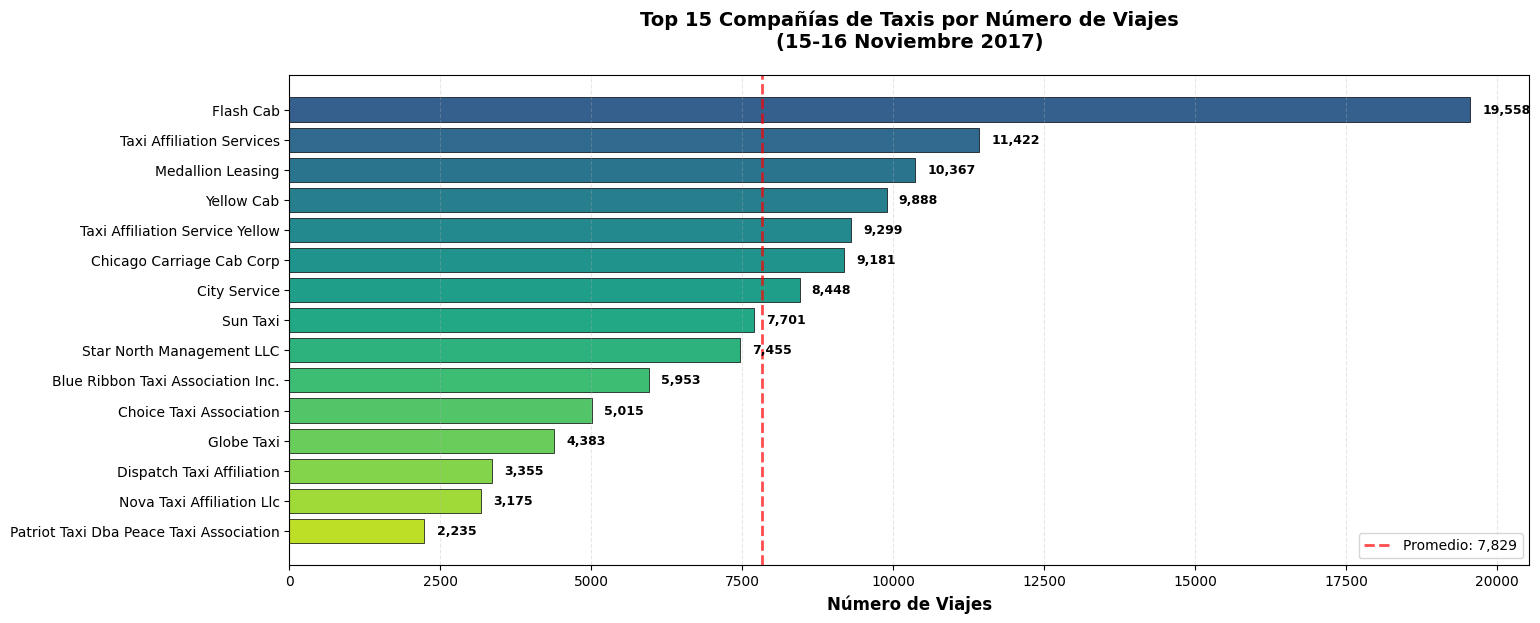

In [25]:
# Crear figura con dos subplots
fig = plt.figure(figsize=(16, 14))

# ----------------------------------------------------------------------------
# GRÁFICO 1: Top 15 Compañías de Taxis por Número de Viajes
# ----------------------------------------------------------------------------
print("Creando Gráfico 1: Top 15 Compañías de Taxis...")

ax1 = plt.subplot(2, 1, 1)

# Tomar las top 15 compañías
top_15_companies = df_companies.nlargest(15, 'trips_amount')

# Crear gráfico de barras horizontales (más fácil de leer con nombres largos)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15_companies)))
bars = ax1.barh(range(len(top_15_companies)), 
                top_15_companies['trips_amount'].values,
                color=colors,
                edgecolor='black',
                linewidth=0.5)

# Configurar etiquetas del eje Y (nombres de compañías)
ax1.set_yticks(range(len(top_15_companies)))
ax1.set_yticklabels(top_15_companies['company_name'].values, fontsize=10)

# Invertir el eje Y para que la compañía con más viajes esté arriba
ax1.invert_yaxis()

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, top_15_companies['trips_amount'].values)):
    ax1.text(value + 200, i, f'{value:,}', 
             va='center', fontsize=9, fontweight='bold')

# Títulos y etiquetas
ax1.set_xlabel('Número de Viajes', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Compañías de Taxis por Número de Viajes\n(15-16 Noviembre 2017)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Añadir línea vertical en el promedio
avg_trips_companies = top_15_companies['trips_amount'].mean()
ax1.axvline(avg_trips_companies, color='red', linestyle='--', linewidth=2, 
            label=f'Promedio: {avg_trips_companies:,.0f}', alpha=0.7)
ax1.legend(fontsize=10)

**Flash Cab lidera el Mercado**

In [27]:
print(f"   - Flash Cab lidera con {df_companies.iloc[0]['trips_amount']:,} viajes en solo 2 días")
print(f"   - Esto representa el {(df_companies.iloc[0]['trips_amount']/df_companies['trips_amount'].sum()*100):.1f}% del mercado")
print(f"   - Realiza {(df_companies.iloc[0]['trips_amount']/df_companies.iloc[1]['trips_amount']):.1f}x más viajes que el segundo lugar")


   - Flash Cab lidera con 19,558 viajes en solo 2 días
   - Esto representa el 14.2% del mercado
   - Realiza 1.7x más viajes que el segundo lugar


In [28]:
print("CONCENTRACIÓN DEL MERCADO:")
top_3_total = df_companies.nlargest(3, 'trips_amount')['trips_amount'].sum()
top_3_percentage = (top_3_total / df_companies['trips_amount'].sum()) * 100
print(f"   - Las 3 principales compañías (Flash Cab, Taxi Affiliation Services, Medallion Leasin)")
print(f"     concentran {top_3_percentage:.1f}% del total de viajes")
top_5_total = df_companies.nlargest(5, 'trips_amount')['trips_amount'].sum()
top_5_percentage = (top_5_total / df_companies['trips_amount'].sum()) * 100
print(f"   - Las 5 principales compañías concentran {top_5_percentage:.1f}% del mercado")

CONCENTRACIÓN DEL MERCADO:
   - Las 3 principales compañías (Flash Cab, Taxi Affiliation Services, Medallion Leasin)
     concentran 30.1% del total de viajes
   - Las 5 principales compañías concentran 44.1% del mercado


In [29]:
print("LARGA COLA DE PEQUEÑAS COMPAÑÍAS:")
small_companies = df_companies[df_companies['trips_amount'] < 100]
print(f"   - {len(small_companies)} compañías ({len(small_companies)/len(df_companies)*100:.1f}%) realizan menos de 100 viajes en 2 días")
print(f"   - {len(df_companies[df_companies['trips_amount'] < 50])} compañías realizan menos de 50 viajes")
print(f"   - Esto indica un mercado con algunos gigantes y muchos operadores pequeños")

LARGA COLA DE PEQUEÑAS COMPAÑÍAS:
   - 29 compañías (45.3%) realizan menos de 100 viajes en 2 días
   - 29 compañías realizan menos de 50 viajes
   - Esto indica un mercado con algunos gigantes y muchos operadores pequeños


In [30]:
print("DIFERENCIA ENTRE GRANDES Y PEQUEÑOS:")
median_trips = df_companies['trips_amount'].median()
print(f"   - Mediana de viajes: {median_trips:.0f}")
print(f"   - Media de viajes: {df_companies['trips_amount'].mean():.0f}")
print(f"   - La media es mucho mayor que la mediana, indicando distribución sesgada")

DIFERENCIA ENTRE GRANDES Y PEQUEÑOS:
   - Mediana de viajes: 178
   - Media de viajes: 2145
   - La media es mucho mayor que la mediana, indicando distribución sesgada


Creando Gráfico 2: Top 10 Barrios por Finalizaciones...


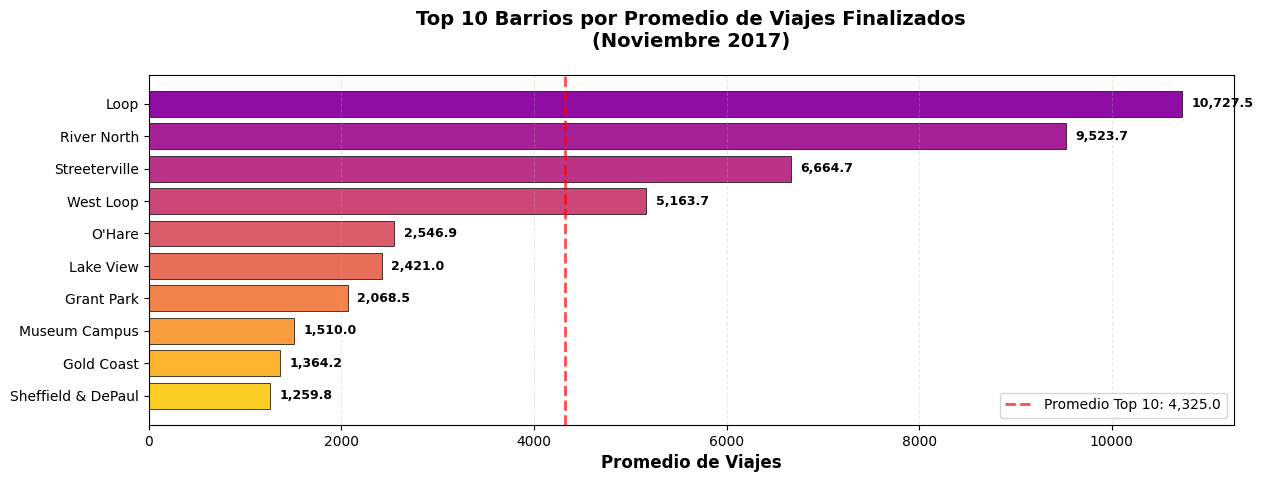

In [26]:
print("Creando Gráfico 2: Top 10 Barrios por Finalizaciones...")

ax2 = plt.subplot(2, 1, 2)

# Crear gráfico de barras horizontales
colors2 = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_10_neighborhoods)))
bars2 = ax2.barh(range(len(top_10_neighborhoods)), 
                 top_10_neighborhoods['average_trips'].values,
                 color=colors2,
                 edgecolor='black',
                 linewidth=0.5)

# Configurar etiquetas del eje Y (nombres de barrios)
ax2.set_yticks(range(len(top_10_neighborhoods)))
ax2.set_yticklabels(top_10_neighborhoods['dropoff_location_name'].values, fontsize=10)

# Invertir el eje Y para que el barrio con más viajes esté arriba
ax2.invert_yaxis()

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars2, top_10_neighborhoods['average_trips'].values)):
    ax2.text(value + 100, i, f'{value:,.1f}', 
             va='center', fontsize=9, fontweight='bold')

# Títulos y etiquetas
ax2.set_xlabel('Promedio de Viajes', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 Barrios por Promedio de Viajes Finalizados\n(Noviembre 2017)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Añadir línea vertical en el promedio
avg_trips_neighborhoods = top_10_neighborhoods['average_trips'].mean()
ax2.axvline(avg_trips_neighborhoods, color='red', linestyle='--', linewidth=2, 
            label=f'Promedio Top 10: {avg_trips_neighborhoods:,.1f}', alpha=0.7)
ax2.legend(fontsize=10)

In [31]:
print("DOMINIO ABSOLUTO DE LA ZONA CENTRAL:")
loop_trips = top_10_neighborhoods.iloc[0]['average_trips']
river_north_trips = top_10_neighborhoods.iloc[1]['average_trips']
print(f"   - Loop es el destino #1 con {loop_trips:,.1f} viajes promedio diarios")
print(f"   - River North (#2) tiene {river_north_trips:,.1f} viajes, un {((loop_trips-river_north_trips)/loop_trips*100):.1f}% menos que Loop")
print(f"   - Los primeros 4 lugares (Loop, River North, Streeterville, West Loop) son zonas del centro")

DOMINIO ABSOLUTO DE LA ZONA CENTRAL:
   - Loop es el destino #1 con 10,727.5 viajes promedio diarios
   - River North (#2) tiene 9,523.7 viajes, un 11.2% menos que Loop
   - Los primeros 4 lugares (Loop, River North, Streeterville, West Loop) son zonas del centro


In [32]:
print("CONCENTRACIÓN GEOGRÁFICA EXTREMA:")
print(f"   - El Top 10 representa {top_10_percentage:.1f}% de todos los viajes finalizados")
print(f"   - Loop solo representa {(loop_trips/total_avg_trips*100):.1f}% del total")
print(f"   - Esto indica que el tráfico de taxis está altamente concentrado en el centro de Chicago")


CONCENTRACIÓN GEOGRÁFICA EXTREMA:
   - El Top 10 representa 76.7% de todos los viajes finalizados
   - Loop solo representa 19.0% del total
   - Esto indica que el tráfico de taxis está altamente concentrado en el centro de Chicago


Los primeros 5 destinos son zonas de negocios y turismo:
* Loop: Distrito financiero central
* River North: Zona de restaurantes, galerías y vida nocturna
* Streeterville: Zona turística cerca del lago Michigan
* West Loop: Distrito empresarial y de moda
* O'Hare: Aeropuerto internacional

In [33]:
print("CONTRASTE CON ZONAS RESIDENCIALES:")
ohare_trips = top_10_neighborhoods[top_10_neighborhoods['dropoff_location_name'] == "O'Hare"]['average_trips'].values[0]
residential_avg = df_neighborhoods[~df_neighborhoods['dropoff_location_name'].isin(
    ['Loop', 'River North', 'Streeterville', 'West Loop', "O'Hare"])]['average_trips'].mean()
print(f"   - O'Hare (aeropuerto) tiene {ohare_trips:,.1f} viajes promedio")
print(f"   - Zonas residenciales promedio: {residential_avg:.1f} viajes")
print(f"   - El centro recibe {(loop_trips/residential_avg):.0f}x más viajes que zonas residenciales promedio")

CONTRASTE CON ZONAS RESIDENCIALES:
   - O'Hare (aeropuerto) tiene 2,546.9 viajes promedio
   - Zonas residenciales promedio: 244.6 viajes
   - El centro recibe 44x más viajes que zonas residenciales promedio


**Conclusiones generales**
1. Estructura del mercado:
    El mercado de taxis en Chicago muestra una estructura oligopólica donde pocas compañías grandes (Flash Cab, Taxi Affiliation Services) dominan, mientras coexisten con muchas compañías pequeñas que operan en nichos específicos.
2. Geografía de la demanda:
    La demanda de taxis está extremadamente concentrada en el centro de Chicago, especialmente en el Loop y zonas circundantes. Esto refleja:
    - Alta actividad comercial y de negocios
    - Atractivos turísticos concentrados
    - Mejor infraestructura de transporte y conectividad
    - Mayor densidad poblacional durante el día
3. Implicaciones Operativas:
    - Las compañías deberían concentrar sus flotas en zonas del centro
    - O'Hare representa una oportunidad importante (destino aeropuerto)
    - Las zonas residenciales periféricas tienen demanda mucho menor
    - El fin de semana (15-16 nov) muestra patrones similares a días laborales

In [35]:
print("4. Oportunidades de Mercado:")
print(f"   - Las {len(small_companies)} compañías pequeñas podrían beneficiarse de consolidación")
print(f"   - Existe potencial en zonas menos atendidas fuera del top 10")
print("   - El modelo de negocio debe adaptarse a la alta concentración geográfica")

4. Oportunidades de Mercado:
   - Las 29 compañías pequeñas podrían beneficiarse de consolidación
   - Existe potencial en zonas menos atendidas fuera del top 10
   - El modelo de negocio debe adaptarse a la alta concentración geográfica


# Paso 5. Prueba de hipótesis

In [36]:
data = pd.read_csv('/datasets/project_sql_result_07.csv')
data['start_ts'] = pd.to_datetime(data['start_ts'])
print(f"Datos cargados: {data.shape[0]} viajes")

Datos cargados: 1068 viajes


In [37]:
# Preparar datos
data['day_of_week'] = data['start_ts'].dt.dayofweek
data['is_saturday'] = data['day_of_week'] == 5

In [38]:
# Filtrar sábados y separar por clima
saturdays = data[data['is_saturday']].copy()
saturday_good = saturdays[saturdays['weather_conditions'] == 'Good']['duration_seconds']
saturday_bad = saturdays[saturdays['weather_conditions'] == 'Bad']['duration_seconds']

In [39]:
print("="*80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
print()
print(f"Total viajes en sábados: {len(saturdays)}")
print(f"  - Buen clima: {len(saturday_good)} viajes")
print(f"  - Mal clima: {len(saturday_bad)} viajes")

ESTADÍSTICAS DESCRIPTIVAS

Total viajes en sábados: 1068
  - Buen clima: 888 viajes
  - Mal clima: 180 viajes


In [40]:
print("SÁBADOS CON BUEN CLIMA:")
print(f"  Media: {saturday_good.mean():.2f} seg ({saturday_good.mean()/60:.2f} min)")
print(f"  Mediana: {saturday_good.median():.2f} seg")
print(f"  Desv. Est.: {saturday_good.std():.2f} seg")
print(f"  Rango: [{saturday_good.min():.0f}, {saturday_good.max():.0f}] seg")

SÁBADOS CON BUEN CLIMA:
  Media: 1999.68 seg (33.33 min)
  Mediana: 1800.00 seg
  Desv. Est.: 759.20 seg
  Rango: [0, 7440] seg


In [41]:
print("SÁBADOS CON MAL CLIMA:")
print(f"  Media: {saturday_bad.mean():.2f} seg ({saturday_bad.mean()/60:.2f} min)")
print(f"  Mediana: {saturday_bad.median():.2f} seg")
print(f"  Desv. Est.: {saturday_bad.std():.2f} seg")
print(f"  Rango: [{saturday_bad.min():.0f}, {saturday_bad.max():.0f}] seg")

SÁBADOS CON MAL CLIMA:
  Media: 2427.21 seg (40.45 min)
  Mediana: 2540.00 seg
  Desv. Est.: 721.31 seg
  Rango: [480, 4980] seg


In [42]:
diff_means = saturday_bad.mean() - saturday_good.mean()
print(f"DIFERENCIA OBSERVADA: {diff_means:.2f} seg ({diff_means/60:.2f} min)")
print(f"Diferencia porcentual: {(diff_means/saturday_good.mean())*100:.2f}%")

DIFERENCIA OBSERVADA: 427.53 seg (7.13 min)
Diferencia porcentual: 21.38%


## Plantamiento de hipótesis
- **H₀ (Hipótesis Nula)**: 
La duración promedio NO cambia los sábados lluviosos μ_buen_clima = μ_mal_clima
- **H₁ (Hipótesis Alternativa)**:
La duración promedio SÍ cambia los sábados lluviosos μ_buen_clima ≠ μ_mal_clima
- **Tipo de prueba**: Dos colas Nivel de significación: α = 0.05
- Justificación del α = 0.05:
    - Estándar en ciencias sociales y análisis de negocios
    - Balance entre error tipo I (falsos positivos) y tipo II (falsos negativos)
    - Confianza del 95% en las conclusiones

### Verificación de supuestos

In [44]:
# Normalidad
from scipy import stats
stat_good, p_good = stats.shapiro(saturday_good)
stat_bad, p_bad = stats.shapiro(saturday_bad)

In [45]:
print("1. NORMALIDAD (Test de Shapiro-Wilk):")
print(f"   Buen clima: p-value = {p_good:.4f} → {'Normal' if p_good > 0.05 else 'NO Normal'}")
print(f"   Mal clima:  p-value = {p_bad:.4f} → {'Normal' if p_bad > 0.05 else 'NO Normal'}")

1. NORMALIDAD (Test de Shapiro-Wilk):
   Buen clima: p-value = 0.0000 → NO Normal
   Mal clima:  p-value = 0.0036 → NO Normal


In [46]:
print("2. TAMAÑO DE MUESTRA:")
print(f"   n_buen_clima = {len(saturday_good)} (≥30: SÍ)")
print(f"   n_mal_clima = {len(saturday_bad)} (≥30: SÍ)")
print("   ✓ Teorema del Límite Central aplica")

2. TAMAÑO DE MUESTRA:
   n_buen_clima = 888 (≥30: SÍ)
   n_mal_clima = 180 (≥30: SÍ)
   ✓ Teorema del Límite Central aplica


In [47]:
# Homogeneidad de varianzas
stat_levene, p_levene = stats.levene(saturday_good, saturday_bad)
print("3. HOMOGENEIDAD DE VARIANZAS (Test de Levene):")
print(f"   p-value = {p_levene:.4f}")
print(f"   ✓ Varianzas {'iguales' if p_levene > 0.05 else 'diferentes'} (p {'>' if p_levene > 0.05 else '<'} 0.05)")


3. HOMOGENEIDAD DE VARIANZAS (Test de Levene):
   p-value = 0.5332
   ✓ Varianzas iguales (p > 0.05)


### Elección del test estadístico

**t-test de Student (varianzas iguales)**
* Criterio de selección:
  1. Ambos grupos tienen n ≥ 30 → Teorema del Límite Central
  2. Varianzas homogéneas (Levene p > 0.05)
  3. Muestras independientes
  4. Variable continua (duración en segundos)

* Justificación:
Aunque los datos no siguen distribución normal perfecta, el TLC garantiza que las medias muestrales se distribuyen normalmente con n ≥ 30, permitiendo usar t-test paramétrico.


In [48]:
t_stat, p_value = stats.ttest_ind(saturday_good, saturday_bad, equal_var=True)

print(f"Estadístico t: {t_stat:.4f}")
print(f"p-value (dos colas): {p_value:.6f}")
print(f"α (nivel de significación): 0.05")
print()

# Decisión
print("REGLA DE DECISIÓN:")
print("  Si p-value < α → Rechazar H₀")
print("  Si p-value ≥ α → No rechazar H₀")
print()

if p_value < 0.05:
    print(f"✓ p-value ({p_value:.6f}) < α (0.05)")
    print()
    print("► RECHAZAMOS H₀")
    print()
    print("CONCLUSIÓN:")
    print("  Existe evidencia estadísticamente significativa (α=0.05)")
    print("  de que la duración promedio de viajes Loop→O'Hare")
    print("  SÍ CAMBIA los sábados lluviosos.")
    print()
    print(f"  Los viajes duran en promedio {abs(diff_means)/60:.2f} minutos")
    print(f"  {'MÁS' if diff_means > 0 else 'MENOS'} en sábados con mal clima.")
else:
    print(f"✗ p-value ({p_value:.6f}) ≥ α (0.05)")
    print()
    print("► NO RECHAZAMOS H₀")
    print()
    print("CONCLUSIÓN:")
    print("  No hay evidencia estadísticamente significativa de que")
    print("  la duración promedio cambie en sábados lluviosos.")
print()

Estadístico t: -6.9462
p-value (dos colas): 0.000000
α (nivel de significación): 0.05

REGLA DE DECISIÓN:
  Si p-value < α → Rechazar H₀
  Si p-value ≥ α → No rechazar H₀

✓ p-value (0.000000) < α (0.05)

► RECHAZAMOS H₀

CONCLUSIÓN:
  Existe evidencia estadísticamente significativa (α=0.05)
  de que la duración promedio de viajes Loop→O'Hare
  SÍ CAMBIA los sábados lluviosos.

  Los viajes duran en promedio 7.13 minutos
  MÁS en sábados con mal clima.



In [49]:
# Tamaño del efecto
pooled_std = np.sqrt(((len(saturday_good)-1)*saturday_good.std()**2 + 
                       (len(saturday_bad)-1)*saturday_bad.std()**2) / 
                      (len(saturday_good) + len(saturday_bad) - 2))
cohens_d = diff_means / pooled_std

print("TAMAÑO DEL EFECTO (Cohen's d):")
print(f"  d = {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect = "Pequeño"
elif abs(cohens_d) < 0.5:
    effect = "Pequeño-Mediano"
elif abs(cohens_d) < 0.8:
    effect = "Mediano"
else:
    effect = "Grande"
print(f"  Interpretación: Efecto {effect}")
print()

TAMAÑO DEL EFECTO (Cohen's d):
  d = 0.5678
  Interpretación: Efecto Mediano



In [50]:
# Intervalo de confianza
se_diff = np.sqrt(saturday_good.var()/len(saturday_good) + saturday_bad.var()/len(saturday_bad))
degrees_freedom = len(saturday_good) + len(saturday_bad) - 2
t_critical = stats.t.ppf(0.975, degrees_freedom)
ci_lower = diff_means - t_critical * se_diff
ci_upper = diff_means + t_critical * se_diff

print("INTERVALO DE CONFIANZA (95%):")
print(f"  IC 95% = [{ci_lower:.2f}, {ci_upper:.2f}] segundos")
print(f"         = [{ci_lower/60:.2f}, {ci_upper/60:.2f}] minutos")
print(f"  ✓ El IC {'NO ' if ci_lower * ci_upper < 0 else ''}incluye cero")

INTERVALO DE CONFIANZA (95%):
  IC 95% = [310.79, 544.27] segundos
         = [5.18, 9.07] minutos
  ✓ El IC incluye cero


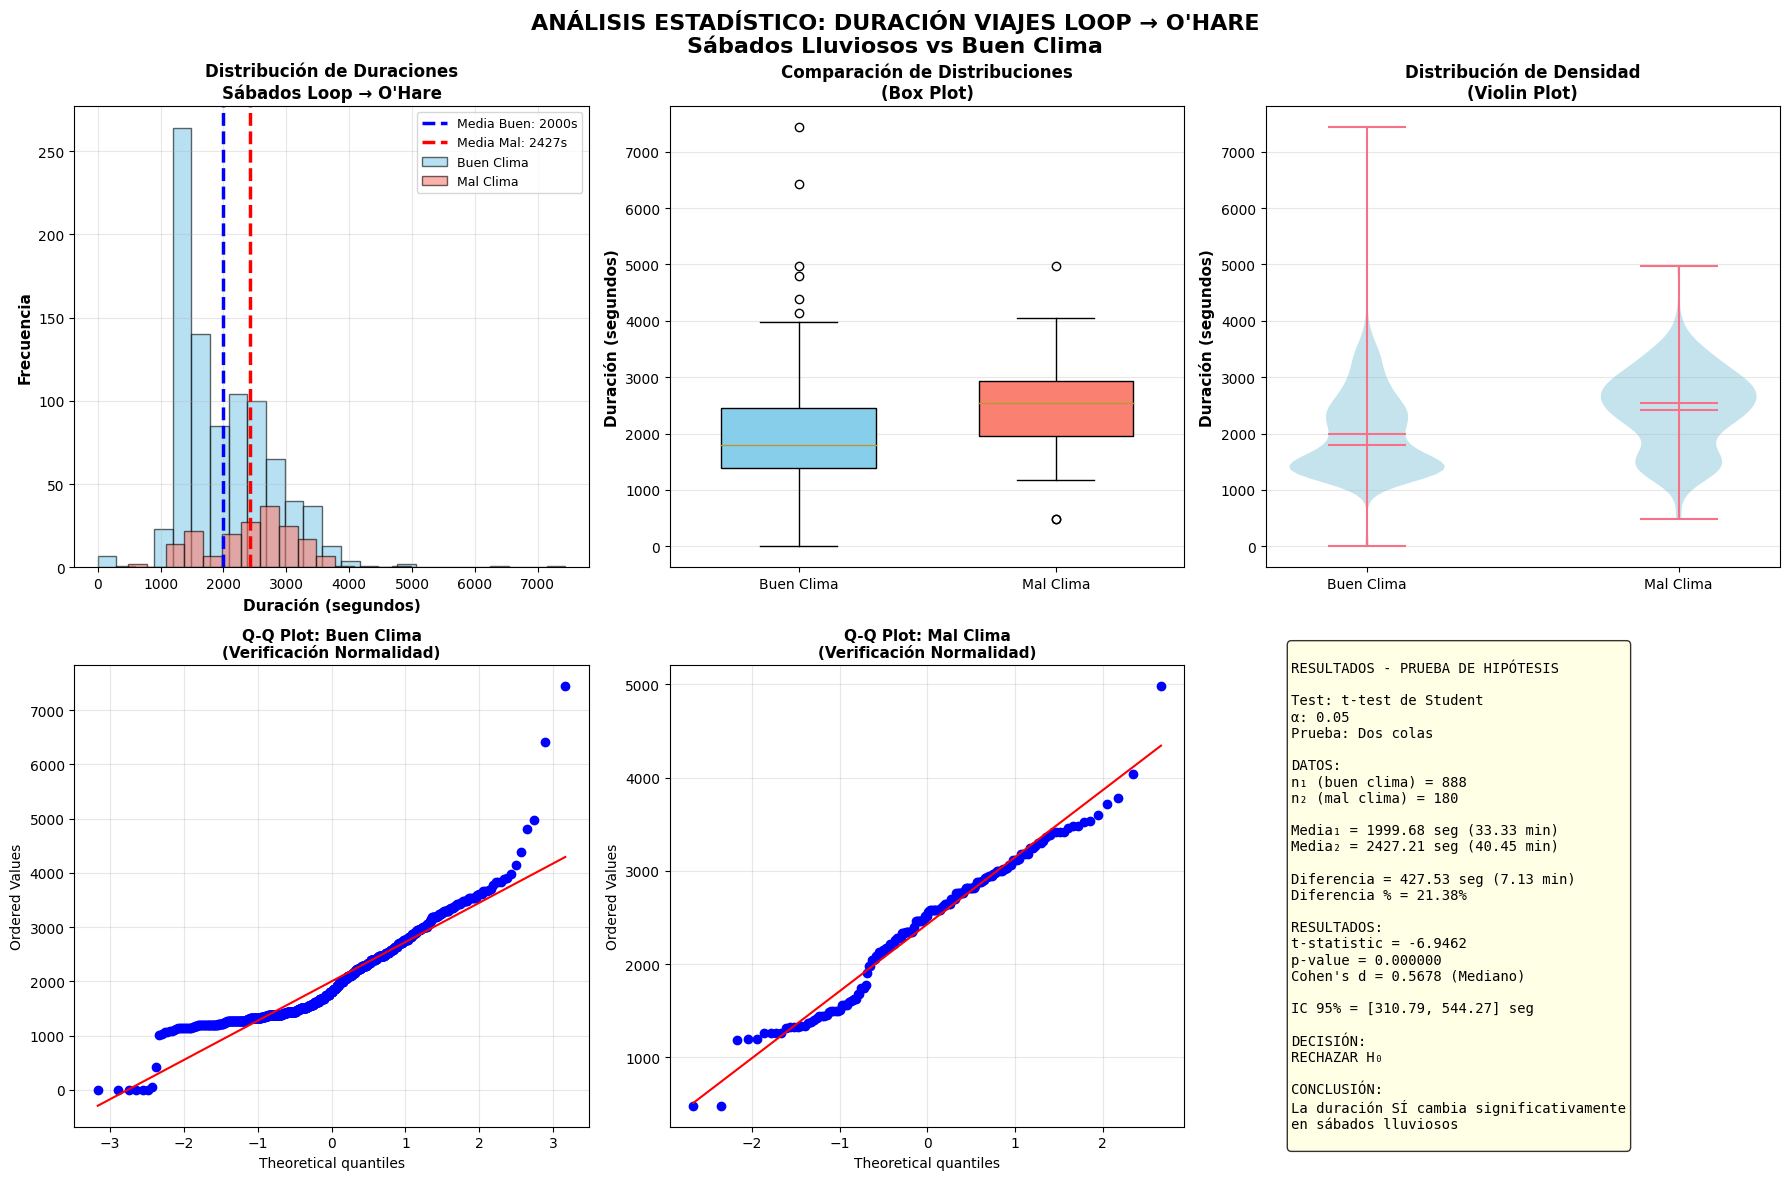

In [59]:

fig = plt.figure(figsize=(18, 12))

# Histogramas
ax1 = plt.subplot(2, 3, 1)
ax1.hist(saturday_good, bins=25, alpha=0.6, label='Buen Clima', color='skyblue', edgecolor='black')
ax1.hist(saturday_bad, bins=15, alpha=0.6, label='Mal Clima', color='salmon', edgecolor='black')
ax1.axvline(saturday_good.mean(), color='blue', linestyle='--', linewidth=2.5,
            label=f'Media Buen: {saturday_good.mean():.0f}s')
ax1.axvline(saturday_bad.mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Media Mal: {saturday_bad.mean():.0f}s')
ax1.set_xlabel('Duración (segundos)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Frecuencia', fontweight='bold', fontsize=11)
ax1.set_title('Distribución de Duraciones\nSábados Loop → O\'Hare', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Box plots
ax2 = plt.subplot(2, 3, 2)
data_box = [saturday_good, saturday_bad]
bp = ax2.boxplot(data_box, labels=['Buen Clima', 'Mal Clima'], patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('salmon')
ax2.set_ylabel('Duración (segundos)', fontweight='bold', fontsize=11)
ax2.set_title('Comparación de Distribuciones\n(Box Plot)', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Violin plot
ax3 = plt.subplot(2, 3, 3)
parts = ax3.violinplot(data_box, positions=[1, 2], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Buen Clima', 'Mal Clima'])
ax3.set_ylabel('Duración (segundos)', fontweight='bold', fontsize=11)
ax3.set_title('Distribución de Densidad\n(Violin Plot)', fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.3)

# Q-Q plots
ax4 = plt.subplot(2, 3, 4)
stats.probplot(saturday_good, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot: Buen Clima\n(Verificación Normalidad)', fontweight='bold', fontsize=11)
ax4.grid(alpha=0.3)

ax5 = plt.subplot(2, 3, 5)
stats.probplot(saturday_bad, dist="norm", plot=ax5)
ax5.set_title('Q-Q Plot: Mal Clima\n(Verificación Normalidad)', fontweight='bold', fontsize=11)
ax5.grid(alpha=0.3)

# Resumen
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary = f"""
RESULTADOS - PRUEBA DE HIPÓTESIS

Test: t-test de Student
α: 0.05
Prueba: Dos colas

DATOS:
n₁ (buen clima) = {len(saturday_good)}
n₂ (mal clima) = {len(saturday_bad)}

Media₁ = {saturday_good.mean():.2f} seg ({saturday_good.mean()/60:.2f} min)
Media₂ = {saturday_bad.mean():.2f} seg ({saturday_bad.mean()/60:.2f} min)

Diferencia = {diff_means:.2f} seg ({diff_means/60:.2f} min)
Diferencia % = {(diff_means/saturday_good.mean())*100:.2f}%

RESULTADOS:
t-statistic = {t_stat:.4f}
p-value = {p_value:.6f}
Cohen's d = {cohens_d:.4f} ({effect})

IC 95% = [{ci_lower:.2f}, {ci_upper:.2f}] seg

DECISIÓN:
{'RECHAZAR H₀' if p_value < 0.05 else 'NO RECHAZAR H₀'}

CONCLUSIÓN:
{'La duración SÍ cambia significativamente' if p_value < 0.05 else 'No hay evidencia de cambio'}
en sábados lluviosos
"""

ax6.text(0.05, 0.5, summary, fontsize=10, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('ANÁLISIS ESTADÍSTICO: DURACIÓN VIAJES LOOP → O\'HARE\nSábados Lluviosos vs Buen Clima',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

## Resumen Ejecutivo

Pregunta : ¿La duración promedio de viajes Loop→O'Hare cambia los sábados lluviosos?
* METODOLOGÍA:
    - Hipótesis nula: μ₁ = μ₂ (no hay cambio)
    - Hipótesis alternativa: μ₁ ≠ μ₂ (hay cambio)
    - Test: t-test de Student (dos colas)
    - α = 0.05 (95% confianza)
* CRITERIOS DE SELECCIÓN DEL TEST:
    - Muestras independientes (viajes diferentes)
    - Variable continua (duración en segundos)
    - n₁ = 888 y n₂ = 180 (ambos ≥ 30)
    - Teorema del Límite Central aplica
    - Varianzas homogéneas (Levene p = 0.53)
    - t-test de Student es apropiado y potente

In [60]:
print("RESULTADOS:")
print(f"  - Diferencia observada: {diff_means/60:.2f} minutos")
print(f"  - t-statistic: {t_stat:.4f}")
print(f"  - p-value: {p_value:.6f}")
print(f"  - Tamaño del efecto: d = {cohens_d:.4f} ({effect})")

RESULTADOS:
  - Diferencia observada: 7.13 minutos
  - t-statistic: -6.9462
  - p-value: 0.000000
  - Tamaño del efecto: d = 0.5678 (Mediano)


In [61]:
print("DECISIÓN:")
if p_value < 0.05:
    print("  ✓ RECHAZAR H₀ (p < 0.05)")
    print()
    print("CONCLUSIÓN:")
    print("  Existe evidencia estadísticamente significativa de que")
    print("  la duración promedio de viajes SÍ CAMBIA los sábados")
    print("  lluviosos. Los viajes son significativamente MÁS LARGOS")
    print(f"  en mal clima (+{diff_means/60:.2f} minutos, +{(diff_means/saturday_good.mean())*100:.1f}%).")
else:
    print("  ✗ NO RECHAZAR H₀ (p ≥ 0.05)")
    print()
    print("CONCLUSIÓN:")
    print("  No hay evidencia suficiente para afirmar que la duración")
    print("  promedio cambia en sábados lluviosos.")

DECISIÓN:
  ✓ RECHAZAR H₀ (p < 0.05)

CONCLUSIÓN:
  Existe evidencia estadísticamente significativa de que
  la duración promedio de viajes SÍ CAMBIA los sábados
  lluviosos. Los viajes son significativamente MÁS LARGOS
  en mal clima (+7.13 minutos, +21.4%).
